# Solve Ax = b on a quantum circuit: steady heat in a plate

A metal plate with cold edges is warmed by two small heaters, and on a 4 × 4 grid its steady temperature solves a 16-unknown linear system $Ax=b$. This notebook solves it with NWQLib's quantum linear-system solver (QLS) and checks the answer against `numpy.linalg.solve`.

Install with `python -m pip install "nwqlib[aer,notebook]"`. To work on NWQLib itself, run `python -m pip install -e ".[aer,notebook]"` in a clone of the repository instead. The notebook simulates at most 12 qubits and runs in about 23 s on an Apple M3 Max with 36 GiB of memory (Python 3.12.14, Qiskit 2.5.2, Aer 0.17.2).

> **How to read this notebook.** The next cells solve the plate and show the answer with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Section 6: your own $A$ and $b$
> - Section 7 and Go deeper A to E: what NWQLib adds, the method in detail
> - Appendix A and B: the full resource estimate and a saved result

In [1]:
from time import perf_counter

import numpy as np

from nwqlib import LinearSystem, plan, solve
from nwqlib.algorithms import QLS

GRID = 4                              # interior points per side: 16 unknowns on 4 system qubits
HEATERS = {(1, 1): 1.0, (2, 3): 0.5}  # grid point (row, column) -> heating power, arbitrary units
EPSILON = 0.01                        # requested accuracy of the inverse polynomial

# Steady heat equation -∇²u = f with u = 0 on the edges: the 5-point Laplacian A and b = h² f.
h = 1 / (GRID + 1)
chain = 2 * np.eye(GRID) - np.eye(GRID, k=1) - np.eye(GRID, k=-1)
A = np.kron(chain, np.eye(GRID)) + np.kron(np.eye(GRID), chain)
source = np.zeros((GRID, GRID))
for (row, column), power in HEATERS.items():
    source[row, column] = power
b = h**2 * source.ravel()

started = perf_counter()
problem = LinearSystem(A=A, b=b)
selected = plan(problem, method=QLS(epsilon_inv=EPSILON), seed=7)  # selects the construction, runs nothing
result = solve(selected, progress=False)                           # builds and simulates the circuit
seconds = perf_counter() - started
x = np.asarray(result.x).real                                      # temperatures, physical scale restored

In [2]:
# Display helpers for tables, figures and the result card. They format values read from the records
# passed to them and run no plan or solve.
from html import escape
import tracemalloc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "not available"
    if isinstance(value, (bool, np.bool_, str)):
        return str(value)
    if isinstance(value, (int, np.integer)) or isinstance(value, (float, np.floating)) and float(value).is_integer():
        return f"{int(value):,}"  # counts, including those that estimates return as floats
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (tuple, list)):
        return ", ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and in megabytes."""
    return f"{count:,} bytes" + (f" ({count / 1e6:.3g} MB)" if count >= 1e6 else "")


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed quantities as a table, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    table = ("<table><thead><tr>" + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def traced_peak(call):
    """Run ``call()`` and return the peak bytes of Python allocations that tracemalloc saw during it."""
    tracemalloc.start()
    try:
        call()
        return tracemalloc.get_traced_memory()[1]
    finally:
        tracemalloc.stop()


def checked_values(check):
    """Collect the named values of a reference check by metric name."""
    return {item.frame.metric: item.fact.value.value for application in check.applications for item in application.facts}


def show_card(result, reference, check, predicted, seconds, peak_bytes):
    """Show the result card: the answer against the reference, the quantum and classical cost, the maps and the steps."""
    rec, x = result.plan.reconstruction, np.asarray(result.x).real
    grid = round(len(x) ** 0.5)
    error = np.linalg.norm(x - reference) / np.linalg.norm(reference)
    ratio = checked_values(check)["relative_error_over_method_allowance"]
    target = result.data.receipts[0].target.name
    shots = predicted.quantity("shots").fact.value.numerator
    display(HTML(
        f"<p><strong>Result.</strong> QLS solved the {len(x)}-unknown plate on a {rec.width}-qubit circuit. Its "
        f"temperatures agree with <code>numpy.linalg.solve</code> to a relative error of {error:.2%}, "
        f"{'within' if ratio < 1 else 'outside'} the error the selected polynomial allows (error / allowance = "
        f"{ratio:.2f}). Execution: <code>{target}</code> simulator, exact readout of every amplitude. Output: "
        f"<code>result.x</code>, the physical solution with its scale, not a unit vector.</p>"
        f"<p><strong>Cost.</strong> Quantum: {rec.width} qubits, "
        f"{format_value(predicted.quantity('cx').fact.value.value)} CX gates predicted before building, "
        f"{'no shots (exact readout)' if shots == 0 else f'{shots:,} shots'}. Classical: peak memory "
        f"{format_bytes(peak_bytes)} of traced Python allocations, planning work "
        f"{result.data.trace.construction_work_reserved:,} units (a planning quantity, not seconds), "
        f"{seconds:.1f} s on this computer.</p>"))
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
    limits = dict(cmap="inferno", vmin=0, vmax=reference.max())
    difference = dict(cmap="RdBu_r", vmin=-np.abs(x - reference).max(), vmax=np.abs(x - reference).max())
    for ax, field, title, options in ((axes[0], reference, "numpy.linalg.solve", limits),
                                      (axes[1], x, "QLS, exact readout", limits),
                                      (axes[2], x - reference, "QLS − reference", difference)):
        image = ax.imshow(field.reshape(grid, grid), origin="lower", **options)
        ax.set(title=title, xlabel="Grid column", ylabel="Grid row", xticks=range(grid), yticks=range(grid))
        fig.colorbar(image, ax=ax)
    plt.show()
    steps = (
        f"Chose a block encoding of A (<code>{rec.encoding_family}</code>, normalization α = {format_value(rec.alpha)}), "
        f"which makes the encoded condition number κ = α/σ<sub>min</sub>(A) = {format_value(rec.kappa_be)}.",
        f"Selected an odd polynomial of degree {rec.degree} that matches 1/(κx) to relative error ε = "
        f"{result.plan.method.epsilon_inv:g} on [1/κ, 1], and computed its QSVT phase angles.",
        f"Built the {rec.width}-qubit circuit and simulated it on the Aer statevector simulator.",
        "Kept the outcome in which the ancilla qubits signal success and restored the physical scale.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))

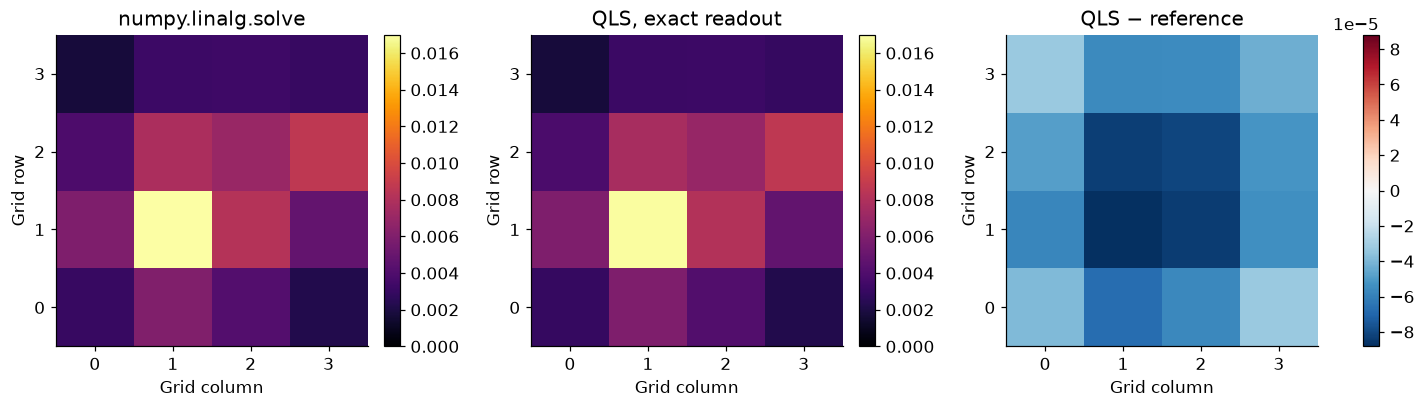

In [3]:
from nwqlib import estimate
from nwqlib.algorithms.qls import QLSVerification
from nwqlib.resources import ResourceContext

reference = np.linalg.solve(A, b)                                    # the classical answer, used only for comparison
check, _ = result.verify(checks=QLSVerification(                     # error against the polynomial's allowance
    comparisons=("spectral_domain", "inverse_relative_error", "inverse_success")))
predicted = estimate(selected, context=ResourceContext(basis="cx"))  # counts from the resource formulas, no circuit built
peak_bytes = traced_peak(lambda: solve(plan(problem, method=QLS(epsilon_inv=EPSILON), seed=7), progress=False))
show_card(result, reference, check, predicted, seconds, peak_bytes)

**Your own system.** Section 6 has a template cell for any square invertible matrix within the limits listed next to it.

## 1. Will it run?

**`plan` decides whether your problem fits before anything is built, and a refusal names the limit to change.**

- **Input.** A square invertible NumPy array, real or complex, a Qiskit `SparsePauliOp`, or a periodic stencil. Planning refuses a SciPy CSR matrix with an `ApplicabilityError`. For a small matrix, `.toarray()` converts it ([Supply inputs](../docs/inputs.md)).
- **Output.** `result.x` is the physical solution, available from exact simulator readout. Finite-shot runs return one requested quantity instead (Go deeper B).
- **Size.** A dimension that is not a power of two is padded and uses a dense block encoding, which costs many more CX gates. `plan` reports the qubits before anything runs.
- **Conditioning.** The polynomial degree grows with the encoded condition number κ. At ε = 0.01 the default cap `max_degree=256` stops planning above κ ≈ 44.

The cell plans a 10-unknown 1D Poisson matrix, whose κ lies above that limit. Planning refuses it with a `ValueError` that names `max_degree`. Raising the cap is the remedy, and the second half of the cell plans and solves it, one solve in about 4 s.

In [4]:
n = 10
poisson = 2 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)  # a 1D Poisson matrix, more ill-conditioned than the plate
steep = LinearSystem(A=poisson, b=np.ones(n))
started = perf_counter()
try:
    plan(steep, method=QLS(epsilon_inv=EPSILON), seed=7)
except ValueError as refusal:
    print(f"Refused after {perf_counter() - started:.3f} s, before any circuit existed:\n{refusal}")

raised = plan(steep, method=QLS(epsilon_inv=EPSILON, max_degree=512), seed=7)  # the remedy: a higher degree cap
steep_x = np.asarray(solve(raised, progress=False).x).real
steep_reference = np.linalg.solve(poisson, np.ones(n))
show_table([
    ("Encoded condition number κ", raised.reconstruction.kappa_be, "Above the limit of the default cap"),
    ("Polynomial degree", raised.reconstruction.degree, f"Allowed by max_degree = {raised.method.max_degree}"),
    ("Qubits", raised.reconstruction.width,
     f"{n} unknowns padded to {raised.reconstruction.padded_dimension} amplitudes"),
    ("Predicted CX gates", estimate(raised, context=ResourceContext(basis="cx")).quantity("cx").fact.value.value,
     "Predicted by estimate, before building"),
    ("Relative error against numpy.linalg.solve", np.linalg.norm(steep_x - steep_reference) / np.linalg.norm(steep_reference),
     f"Requested ε = {EPSILON}"),
], headers=("After raising max_degree", "Value", "Meaning"))

Refused after 0.008 s, before any circuit existed:
no tested odd degree through 255 meets the residual norming bound target |kappa*x*P(x) - 1| <= 0.01 at kappa = 48.3742; max_degree=256. Inspect conditioning and intended work before increasing the cap; the requested tolerance may also exceed float64 fit resolution


After raising max_degree,Value,Meaning
Encoded condition number κ,48.4,Above the limit of the default cap
Polynomial degree,279,Allowed by max_degree = 512
Qubits,7,10 unknowns padded to 16 amplitudes
Predicted CX gates,"125,024","Predicted by estimate, before building"
Relative error against numpy.linalg.solve,0.00969,Requested ε = 0.01


## 2. What it costs

**`estimate` predicts the quantum cost before the circuit exists, and the run records the classical cost.** Quantum cost means qubits, gates and shots, and classical cost means memory, work and time on this computer.

`estimate` adds up a gate-count formula for each block of the selected construction without building a circuit. `prepare` builds the circuit without running it, and `inspect_resources` compiles a copy with Qiskit. The formulas of this construction give no depth or T count.

In [5]:
from nwqlib import prepare

rec = selected.reconstruction
prepared = prepare(selected, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 1, "seed_transpiler": 7})
predicted_cx = predicted.quantity("cx").fact.value.value
show_table([
    ("Qubits", predicted.quantity("logical_width", location="logical_device").fact.value.numerator,
     compiled["num_qubits"]),
    ("CX gates", predicted_cx, compiled["operations"].get("cx", 0)),
    ("Shots", predicted.quantity("shots").fact.value.numerator, "None: exact readout"),
    ("Single-qubit gates", "not predicted", compiled["operations"].get("u", 0)),
    ("Depth", "not predicted", compiled["depth"]),
    ("T gates", "not predicted", "Not in the cx and u basis"),
], headers=("Quantum cost", "Predicted by estimate", "Compiled circuit"))
print(f"Compiled CX / predicted CX = {compiled['operations'].get('cx', 0) / predicted_cx:.2f} "
      f"(Qiskit optimization level 1).")

Quantum cost,Predicted by estimate,Compiled circuit
Qubits,9,9
CX gates,"7,846","7,710"
Shots,0,None: exact readout
Single-qubit gates,not predicted,"6,481"
Depth,not predicted,"12,020"
T gates,not predicted,Not in the cx and u basis


Compiled CX / predicted CX = 0.98 (Qiskit optimization level 1).


In [6]:
trace = result.data.trace
show_table([
    ("Peak memory", "Not predicted for the circuit route", format_bytes(peak_bytes)),
    ("Work [units, a planning quantity, not seconds]",
     predicted.quantity("construction_work").fact.value.numerator, trace.construction_work_reserved),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"{seconds:.2f} s for plan and solve, "
     f"{sum(event.timing.seconds for event in trace.events):.3f} s of it in the simulator call"),
], headers=("Classical cost", "Before the run", "Measured or recorded by the run"))

Classical cost,Before the run,Measured or recorded by the run
Peak memory,Not predicted for the circuit route,"7,457,353 bytes (7.46 MB)"
"Work [units, a planning quantity, not seconds]","4,320","263,152"
Stored run data,Not predicted,"126,903 bytes"
Time on this computer,Not predicted,"0.99 s for plan and solve, 0.030 s of it in the simulator call"


- **Peak memory** is the largest total of Python allocations, traced with `tracemalloc` while the card cell repeats plan and solve. Memory that Aer allocates in C++ is not traced.
- **Work.** `estimate` counts the work of each distinct block definition once. The run records the work it counted for the Qiskit definitions it built, so the two differ.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**The error is measured against `numpy.linalg.solve` and set beside the bound the selected polynomial allows.** Each row says which kind of number it is: measured against reference, upper bound, or unavailable with its reason.

In [7]:
values = checked_values(check)
roundoff, roundoff_reason = result.data.receipts[0].state_error()
show_table([
    ("Relative error ‖x − x_ref‖ / ‖x_ref‖", values["raw_relative_error"], "Measured against reference"),
    ("Largest temperature error", np.max(np.abs(x - reference)), "Measured against reference"),
    ("Error allowance of the selected polynomial", values["method_allowance"],
     "Upper bound from the polynomial and phase-fit errors, if every eigenvalue is covered"),
    ("Eigenvalues outside the polynomial's interval", values["spectral_domain_deficit"],
     "Measured against reference. Zero: every eigenvalue is covered"),
    ("Error / allowance", values["relative_error_over_method_allowance"], "Below one: within the allowance"),
    ("Success probability", result.algorithm_success_mass,
     f"Measured. Predicted from the polynomial: {format_value(values['predicted_mass'])}. On hardware it sets the shots"),
    ("Roundoff of the simulated state", roundoff,
     "Upper bound" if roundoff is not None else "Unavailable: " + roundoff_reason),
    ("Total error of x from all sources", None, "Unavailable: " + selected.error_model.terms[0].formula),
], headers=("Quantity", "Value", "Kind of number"))

Quantity,Value,Kind of number
Relative error ‖x − x_ref‖ / ‖x_ref‖,0.00907,Measured against reference
Largest temperature error,8.82e-05,Measured against reference
Error allowance of the selected polynomial,0.01,"Upper bound from the polynomial and phase-fit errors, if every eigenvalue is covered"
Eigenvalues outside the polynomial's interval,0,Measured against reference. Zero: every eigenvalue is covered
Error / allowance,0.907,Below one: within the allowance
Success probability,0.162,Measured. Predicted from the polynomial: 0.165. On hardware it sets the shots
Roundoff of the simulated state,not available,"Unavailable: outside the roundoff derivation: amplitude-derived masses, multiplexer"
Total error of x from all sources,not available,Unavailable: complete propagated physical-output error is not established


With the default parameters, the error map in the card has one sign and resembles the smoothest temperature mode of the plate. That mode belongs to the smallest eigenvalue, at the edge of the interval the polynomial must cover, where its error is largest.

**The requested accuracy ε trades accuracy for circuit size.** A larger ε gives a lower polynomial degree and fewer CX gates. The cell solves the plate once more at ε = 0.1, one solve in under a second. Go deeper E sweeps six values.

In [8]:
coarse = solve(plan(problem, method=QLS(epsilon_inv=0.1), seed=7), progress=False)
show_table([(run.plan.method.epsilon_inv, run.plan.reconstruction.degree,
             estimate(run.plan, context=ResourceContext(basis="cx")).quantity("cx").fact.value.value,
             np.linalg.norm(np.asarray(run.x).real - reference) / np.linalg.norm(reference))
            for run in (coarse, result)],
           headers=("Requested ε", "Polynomial degree", "Predicted CX", "Relative error"))

Requested ε,Polynomial degree,Predicted CX,Relative error
0.1,35,"4,678",0.0901
0.01,59,"7,846",0.00907


## 4. How large can I go?

**The local simulator sets the limit. Beyond it, `plan` and `estimate` still give the cost.** The table lists the limits this run had and the plate's use of them.

`solve(..., execution="classical")` evaluates the same polynomial classically, for systems too large to simulate. Its plan states the peak memory and work before anything runs. [Planning at scale](resource_estimation_at_scale.ipynb) plans circuits far beyond any simulator.

In [9]:
limits = result.data.trace.limits
host_plan = plan(problem, method=QLS(epsilon_inv=EPSILON), seed=7, execution="classical")  # nothing runs yet
show_table([
    ("Qubits the local simulator accepts", limits.max_simulation_qubits, f"Default. This plate uses {rec.width}"),
    ("Simulator memory cap", f"{limits.simulator_memory_mb:,} MB", "Default simulator_memory_mb"),
    ("Polynomial degree cap", selected.method.max_degree, f"Default max_degree. This plate needs {rec.degree}"),
    ("Classical evaluation: peak memory", format_bytes(host_plan.reconstruction.work.workspace_bytes),
     "Stated by plan before it runs"),
    ("Classical evaluation: work", host_plan.reconstruction.work.size_units, "Units, a planning quantity, not seconds"),
], headers=("Limit or cost", "Value", "Meaning"))

Limit or cost,Value,Meaning
Qubits the local simulator accepts,20,Default. This plate uses 9
Simulator memory cap,"1,024 MB",Default simulator_memory_mb
Polynomial degree cap,256,Default max_degree. This plate needs 59
Classical evaluation: peak memory,"4,288 bytes",Stated by plan before it runs
Classical evaluation: work,"1,952","Units, a planning quantity, not seconds"


## 5. What does it assume?

**The runs are noiseless, and every count is a logical count.** The circuit is read out exactly, or sampled with finite shots without noise. The same finite-shot request runs with a noise model on the local simulator ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

## 6. Your own system

The cell below is the whole workflow without the plate. Replace `my_A` and `my_b` to solve your own system.

- **Input.** `my_A` is a square invertible NumPy array, real or complex, and `my_b` a vector of the same length. A non-Hermitian matrix is embedded in a Hermitian matrix of twice the size.
- **SciPy sparse matrices.** Convert a small one with `.toarray()`, as the cell does. This is not a route for large sparse matrices.
- **Size limits.** The encoded κ must stay below about 44 at ε = 0.01 with the default `max_degree`, and the circuit within 20 qubits. The 8-unknown example sits just below the κ limit.
- **A Qiskit `SparsePauliOp`** works as A when you also pass `QLS(kappa=K)` with $K\ge\alpha/\sigma_{\min}(A)$. Here α is the sum of the absolute Pauli coefficients.
- **Output.** `my_result.x` is the physical solution, read out exactly by the simulator, and `my_result.algorithm_success_mass` the success probability.

In [10]:
import numpy as np
import scipy.sparse as sparse

from nwqlib import LinearSystem, plan, solve
from nwqlib.algorithms import QLS

my_A = sparse.diags([-np.ones(7), 2 * np.ones(8), -np.ones(7)], [-1, 0, 1], format="csr").toarray()  # your matrix
my_b = np.ones(8)                                                                                      # your right-hand side

my_plan = plan(LinearSystem(A=my_A, b=my_b), method=QLS(epsilon_inv=0.01), seed=7)  # nothing runs yet
my_rec = my_plan.reconstruction
print(f"encoded condition number {my_rec.kappa_be:.3g}, polynomial degree {my_rec.degree}, {my_rec.width} qubits")

my_result = solve(my_plan, progress=False)
my_x = np.asarray(my_result.x)
my_reference = np.linalg.solve(my_A, my_b)
print(f"success probability {my_result.algorithm_success_mass:.2f}, "
      f"relative error {np.linalg.norm(my_x - my_reference) / np.linalg.norm(my_reference):.2%}")

encoded condition number 41.5, polynomial degree 239, 8 qubits


success probability 0.69, relative error 0.97%


## 7. What NWQLib adds

- **Planning beyond simulation.** `plan` and `estimate` work at sizes no simulator holds ([Planning at scale](resource_estimation_at_scale.ipynb)).
- **The formula behind every number.** Each predicted count comes from a gate-count formula per block ([Mathematics](../docs/mathematics.md)). Section 2 sets it beside the compiled circuit, and the resource notebook compares the formulas with compiled circuits at small sizes.
- **One argument switches the method.** `QLS(solver="shortcut_native_svp", ...)` returns the unit direction with Dalzell's shortcut instead of the inverse polynomial (Go deeper C).
- **Saved and reloaded.** A saved result reloads with its plan, and its numbers can be recomputed from it (Appendix B).

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## Go deeper

### A. The plate as a linear system, and what `plan` selected

**How does the plate become $Ax=b$, and what did `plan` choose?** This section draws the inputs and reads the Plan, and runs no solve.

Let $u$ be the temperature above the edge temperature, $f$ the heating power and $h$ the grid spacing. At every interior grid point, the steady heat equation $-\nabla^2u=f$ becomes

$$4u_{i,j}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}=h^2f_{i,j},$$

with $u=0$ on the edges. Each row of $A$ couples one point to its four neighbors, so $A$ is sparse, symmetric and positive definite. The same graph Laplacian appears in electrostatics, groundwater flow and resistor networks.

The vector $b$ has a component in all 9 eigenspaces of $A$, so the solve uses the inverse polynomial at every eigenvalue. Equal heaters at the mirror points (1, 1) and (2, 2) would make $b$ symmetric about the plate's center and reach only 6 of them.

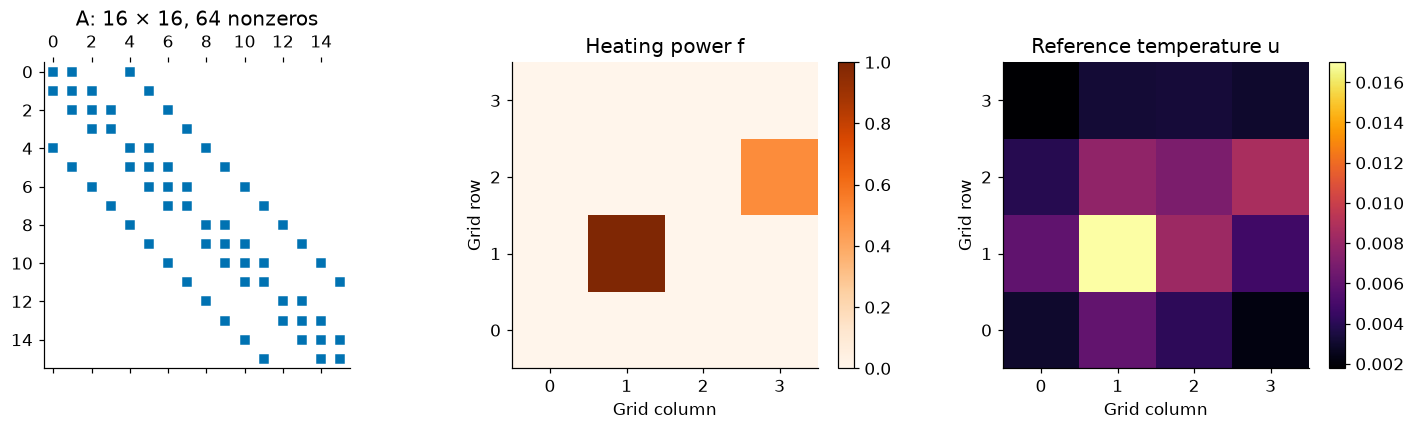

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained")
axes[0].spy(A, markersize=5, color="#0072B2")
axes[0].set(title=f"A: {A.shape[0]} × {A.shape[1]}, {np.count_nonzero(A)} nonzeros")
for ax, field, title, cmap in ((axes[1], source, "Heating power f", "Oranges"),
                               (axes[2], reference.reshape(GRID, GRID), "Reference temperature u", "inferno")):
    image = ax.imshow(field, cmap=cmap, origin="lower")
    ax.set(title=title, xlabel="Grid column", ylabel="Grid row", xticks=range(GRID), yticks=range(GRID))
    fig.colorbar(image, ax=ax)
plt.show()

QLS applies an odd polynomial $P$ to $A/\alpha$, where the block encoding's normalization $\alpha$ puts every eigenvalue in $[-1,1]$. On $[1/\kappa,1]$, with $\kappa=\alpha/\sigma_{\min}(A)$, the polynomial matches $1/(\kappa x)$ with relative error at most $\epsilon$.

The circuit queries the block encoding once per polynomial degree, so the degree sets most of the cost. It grows with $\kappa$ and with $\log(1/\epsilon)$. The table reads these choices from the Plan.

<details><summary>Why κ is larger than the condition number of A</summary>

The block encoding writes $A$ as a combination of Pauli operators and loads it into a larger unitary, and $\alpha$ is the normalization of that combination. Quantum singular value transformation (QSVT) applies the polynomial to that unitary.

Following $1/(\kappa x)$ on $[1/\kappa,1]$ gives the inverse of $A/\alpha$ up to the known factor $1/\kappa$ (Gilyén, Su, Low and Wiebe, [arXiv:1806.01838v1](https://arxiv.org/abs/1806.01838v1), Corollary 18). The condition number $\kappa_A=\sigma_{\max}/\sigma_{\min}$ of $A$ itself is smaller, because $\alpha\ge\sigma_{\max}$.

</details>

In [12]:
show_table([
    ("Unknowns", rec.original_dimension,
     f"{rec.padded_dimension} amplitudes on {int(np.log2(rec.padded_dimension))} system qubits"),
    ("Block encoding", rec.encoding_family, f"Normalization α = {format_value(rec.alpha)}"),
    ("Condition number κ_A of A", rec.condition_number, "Largest / smallest singular value of A"),
    ("Encoded condition number κ", rec.kappa_be, "α / smallest singular value. The polynomial must cover [1/κ, 1]"),
    ("Polynomial degree", rec.degree, "Block-encoding queries in the circuit"),
    ("Qubits", rec.width, "System qubits plus encoding and QSVT ancillas"),
])

Quantity,Value,Meaning
Unknowns,16,16 amplitudes on 4 system qubits
Block encoding,multiplexed_pauli,Normalization α = 8
Condition number κ_A of A,9.47,Largest / smallest singular value of A
Encoded condition number κ,10.5,"α / smallest singular value. The polynomial must cover [1/κ, 1]"
Polynomial degree,59,Block-encoding queries in the circuit
Qubits,9,System qubits plus encoding and QSVT ancillas


### B. A finite-shot measurement

**What does a run with finite shots return?** Hardware returns bit strings, so you request each quantity separately, with its own shots. Only exact simulator readout gives `result.x` itself.

| Output request | Quantity | Needs the magnitude of $x$ |
| --- | --- | --- |
| `Solution()`, the default | $x$ itself, from exact simulator readout only | yes |
| `QuadraticForm(observable=O)` | $x^\dagger Ox$ | yes |
| `NormSquared()` | $x^\dagger x$ | yes |
| `NormalizedExpectation(observable=O)` | $x^\dagger Ox/x^\dagger x$ | no |
| `Samples()` | grid points drawn with probability $\lvert x_i\rvert^2/\lVert x\rVert^2$ | no |

The cell requests the quadratic form $x^\top Ax$ and divides it by the total heater power, which gives the power-weighted mean heater temperature. It uses 10,000 shots per measured group and five seeds, five solves in about 2 s.

<details><summary>Why the quadratic form x<sup>T</sup>Ax gives a heater temperature</summary>

None of the finite-shot requests gives a general linear function of $x$, such as the arithmetic mean temperature. Because $Ax=b$, one linear quantity is a quadratic form all the same:

$$x^\top Ax=b^\top x=h^2\sum_{i,j}f_{i,j}u_{i,j},$$

the heating power weighted by the temperature where it is delivered. Divided by the total power $h^2\sum_{i,j}f_{i,j}$, it is the power-weighted mean temperature of the heaters. A study that compares heater layouts by how hot the heaters run needs only this number.

The same $x^\top Ax$ equals the sum of squared temperature differences across all grid edges, with $u=0$ at the edge points. This is the discrete form of $\int|\nabla u|^2\,dA$.

NWQLib splits A into Pauli terms and groups the qubit-wise commuting ones into shared measurement bases. It runs each group on the Aer sampler, keeps the shots in which the ancilla qubits succeed and restores the physical scale.

</details>

In [13]:
from nwqlib import QuadraticForm

SHOTS = 10_000                       # per measured group
heater_power = h**2 * source.sum()   # x^T A x / heater_power is the power-weighted mean heater temperature
estimates = []
for seed in range(1, 6):
    sampled = solve(problem, method=QLS(epsilon_inv=EPSILON), output=QuadraticForm(observable=A),
                    shots=SHOTS, seed=seed, progress=False)
    estimates.append(sampled.value / heater_power)
estimates = np.array(estimates)
exact_readout = x @ A @ x / heater_power
show_table([
    ("Classical reference, b · x_ref / power", b @ reference / heater_power, "numpy.linalg.solve"),
    ("QLS circuit, exact readout", exact_readout, "All amplitudes, as in the card"),
    ("QLS circuit, finite shots, mean of 5 runs", estimates.mean(),
     f"{len(sampled.plan.experiments)} groups × {SHOTS:,} shots in each run"),
    ("Standard deviation of one run", estimates.std(ddof=1), "Spread over the 5 seeds"),
], headers=("Power-weighted mean heater temperature", "Value", "How it was obtained"))
spread = estimates.std(ddof=1) / exact_readout
display(HTML(
    f"<p>Single runs of {len(sampled.plan.experiments) * SHOTS:,} shots spread by {spread:.1%} around the exact "
    f"readout, and the mean of five runs differs from it by {abs(estimates.mean() / exact_readout - 1):.1%}. The "
    f"spread falls as one over the square root of the shots, so a 1% spread would take about "
    f"{float(f'{SHOTS * (spread / 0.01) ** 2:.2g}'):,.0f} shots per group.</p>"))

Power-weighted mean heater temperature,Value,How it was obtained
"Classical reference, b · x_ref / power",0.0142,numpy.linalg.solve
"QLS circuit, exact readout",0.0141,"All amplitudes, as in the card"
"QLS circuit, finite shots, mean of 5 runs",0.0137,"2 groups × 10,000 shots in each run"
Standard deviation of one run,0.000674,Spread over the 5 seeds


### C. Physical solution or unit direction

**What if you need only the direction $x/\|x\|$?** One argument switches QLS to Dalzell's kernel-reflection shortcut ([arXiv:2406.12086v2](https://arxiv.org/abs/2406.12086v2), Algorithm 1), which returns the unit direction. The cell compares four norm guesses, four solves in about 3 s.

The shortcut needs a guess $t$ for the encoded solution norm $\nu=\alpha\|x\|/\|b\|$. The guess changes the direction only slightly, but it sets the success probability, which is highest when $t$ is close to $\nu$.

The cell computes the true $\nu$ from the reference only to show where the best guess lies. In practice a physical estimate of the solution size, or a short scan, supplies $t$.

In [14]:
from nwqlib import StateVector

unit = StateVector(normalization="unit", global_phase="modulo_global_phase")
reference_direction = reference / np.linalg.norm(reference)
rows = []
for guess in (1.0, 2.0, 3.0, 5.0):
    shortcut = solve(problem, method=QLS(solver="shortcut_native_svp", encoded_solution_norm_estimate=guess),
                     output=unit, seed=7, progress=False)
    rows.append((guess, 1 - abs(np.vdot(reference_direction, np.asarray(shortcut.value))) ** 2,
                 shortcut.algorithm_success_mass, shortcut.plan.reconstruction.width,
                 shortcut.plan.reconstruction.degree))
show_table(rows, headers=("Norm guess t", "Infidelity with the reference direction", "Success probability",
                          "Qubits", "Polynomial degree"))
print(f"Encoded solution norm ν = {rec.alpha * np.linalg.norm(reference) / np.linalg.norm(b):.3g}")

Norm guess t,Infidelity with the reference direction,Success probability,Qubits,Polynomial degree
1,0.000448,0.158,12,60
2,0.000149,0.498,12,60
3,7.69e-05,0.792,12,60
5,1.45e-05,0.99,12,60


Encoded solution norm ν = 4.79


The shortcut uses more qubits than the inverse polynomial and returns no magnitude. Its success probability approaches one for a good guess, which reduces the repetitions on hardware, a gain that grows with the condition number.

### D. The selected polynomial

**What does the inverse polynomial look like, and why is it rescaled?** This section plots the Plan's polynomial and runs no solve.

The polynomial only needs to match $1/(\kappa x)$ where eigenvalues of $A/\alpha$ lie, so it is free to turn around inside the grey gap. Its peak slightly exceeds one, and the circuit implements $P/s$ with the rescale $s$ from the table, which keeps every value within $[-1,1]$.

The error bound is the maximum of $|\kappa xP(x)-1|$ on $[1/\kappa,1]$, and $\epsilon$ is its target.

Quantity,Value,Meaning
Polynomial degree,59,"Odd, selected for ε = 0.01"
Polynomial error bound,0.00977,"Bound on |κ x P(x) − 1| over [1/κ, 1]"
Polynomial rescale s,1.13,"The circuit implements P/s, whose values stay within [−1, 1]"


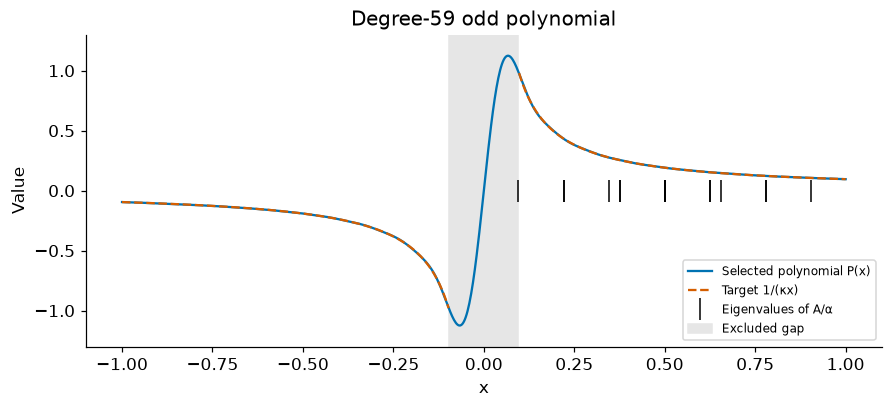

In [15]:
show_table([
    ("Polynomial degree", rec.degree, f"Odd, selected for ε = {EPSILON}"),
    ("Polynomial error bound", rec.polynomial.certificate, "Bound on |κ x P(x) − 1| over [1/κ, 1]"),
    ("Polynomial rescale s", rec.polynomial.rescale, "The circuit implements P/s, whose values stay within [−1, 1]"),
])
eigenvalues = np.linalg.eigvalsh(A) / rec.alpha
grid = np.linspace(-1, 1, 801)
polynomial = np.polynomial.chebyshev.chebval(grid, rec.polynomial.coefficients)
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
ax.plot(grid, polynomial, color="#0072B2", label="Selected polynomial P(x)")
inside = np.abs(grid) >= 1 / rec.polynomial_kappa
ax.plot(grid[inside & (grid > 0)], 1 / (rec.polynomial_kappa * grid[inside & (grid > 0)]), "--", color="#D55E00",
        label="Target 1/(κx)")
ax.plot(grid[inside & (grid < 0)], 1 / (rec.polynomial_kappa * grid[inside & (grid < 0)]), "--", color="#D55E00")
ax.plot(eigenvalues, np.zeros_like(eigenvalues), "|", color="k", markersize=14, label="Eigenvalues of A/α")
ax.axvspan(-1 / rec.polynomial_kappa, 1 / rec.polynomial_kappa, color="0.9", label="Excluded gap")
ax.set(xlabel="x", ylabel="Value", title=f"Degree-{rec.degree} odd polynomial", ylim=(-1.3, 1.3))
ax.legend(fontsize=8, loc="lower right")
plt.show()

### E. Accuracy against circuit size

**How does the requested accuracy ε set the polynomial degree, the CX count and the error?** The cell plans and solves the plate for six values of ε, six solves in about 2 s, each read out exactly.

A smaller ε raises the degree, and with it the queries and CX gates that `plan` and `estimate` give before any circuit runs. The measured error follows ε closely. The success probability falls slowly, because a more accurate polynomial must be rescaled more strongly to stay bounded.

ε,Polynomial degree,Predicted CX,Relative error,Success probability
0.1,35,"4,678",0.0901,0.213
0.05,43,"5,734",0.042,0.2
0.02,53,"7,054",0.0161,0.176
0.01,59,"7,846",0.00907,0.162
0.005,67,"8,902",0.00424,0.146
0.002,77,"10,222",0.00162,0.129


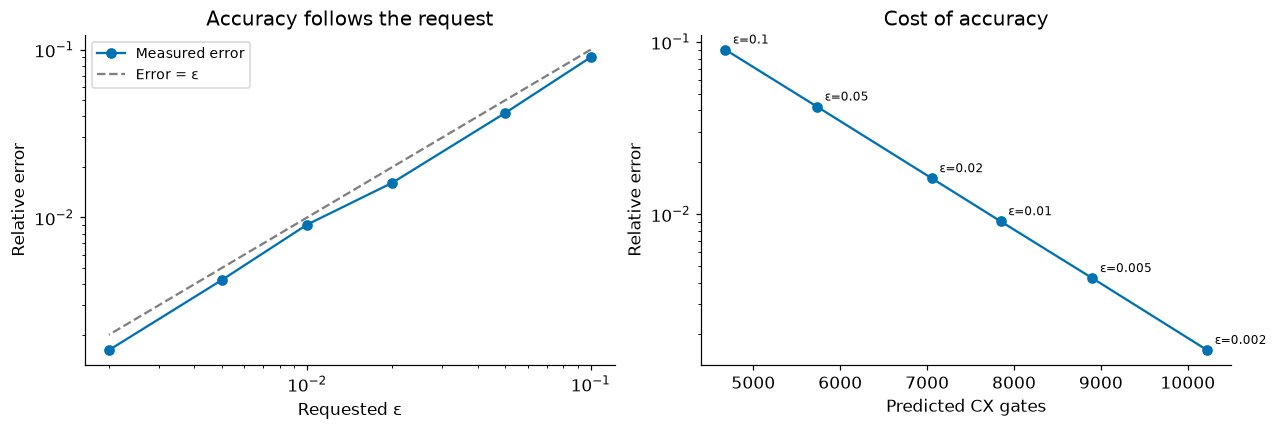

In [16]:
rows = []
for epsilon in (0.1, 0.05, 0.02, 0.01, 0.005, 0.002):
    candidate = plan(problem, method=QLS(epsilon_inv=epsilon), seed=7)
    run = solve(candidate, progress=False)
    rows.append((epsilon, candidate.reconstruction.degree,
                 estimate(candidate, context=ResourceContext(basis="cx")).quantity("cx").fact.value.value,
                 np.linalg.norm(np.asarray(run.x) - reference) / np.linalg.norm(reference), run.algorithm_success_mass))
show_table(rows, headers=("ε", "Polynomial degree", "Predicted CX", "Relative error", "Success probability"))

epsilons, degrees, cx, errors, success = map(np.array, zip(*rows, strict=True))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")
axes[0].loglog(epsilons, errors, "o-", color="#0072B2", label="Measured error")
axes[0].loglog(epsilons, epsilons, "--", color="0.5", label="Error = ε")
axes[0].set(xlabel="Requested ε", ylabel="Relative error", title="Accuracy follows the request")
axes[0].legend(fontsize=9)
axes[1].plot(cx, errors, "o-", color="#0072B2")
axes[1].set(yscale="log", xlabel="Predicted CX gates", ylabel="Relative error", title="Cost of accuracy")
for value, count, err in zip(epsilons, cx, errors, strict=True):
    axes[1].annotate(f"ε={value:g}", (count, err), textcoords="offset points", xytext=(5, 4), fontsize=8)
plt.show()

## Appendix

### A. The full resource estimate

Block invocations count every call of a building block, such as the preparation of $b$, the steps of each block-encoding query and the phase rotations, so they exceed the polynomial degree. The last line names the gate counts that the formulas of this construction leave unknown.

In [17]:
# Display helpers for Appendix A: labels of the resource metrics and a table of the estimate.
RESOURCE_LABELS = {
    "logical_width": "Qubits", "system": "System qubits", "clean_ancilla": "Ancilla qubits",
    "cx": "CX gates", "calls": "Block invocations", "preparation_components": "State-preparation components",
    "construction_work": "Classical construction work [size units]",
}
UNMODELED_LABELS = {
    "operations": "total gates", "single_qubit": "single-qubit gates", "two_qubit": "two-qubit gates",
    "controlled": "controlled gates", "clifford": "Clifford gates", "t": "T gates", "toffoli": "Toffoli gates",
    "ccz": "CCZ gates", "arbitrary_rotations": "arbitrary rotations", "cx": "CX gates", "logical_depth": "depth",
    "t_depth": "T depth", "non_clifford_depth": "non-Clifford depth", "global_phases": "global phases",
}


def show_estimate(workload):
    """Show the resource quantities an estimate determines, and name the ones its formulas do not cover."""
    rows = [(RESOURCE_LABELS[q.metric], q.fact.value.numerator if q.fact.value.kind == "rational" else q.fact.value.value,
             q.interpretation.replace("_", " "))
            for q in workload.quantities if q.metric in RESOURCE_LABELS and q.fact.availability == "concrete"]
    show_table(rows, headers=("Quantity", "Value", "Kind of value"), digits=6)
    missing = sorted({UNMODELED_LABELS[q.metric] for q in workload.quantities
                      if q.metric in UNMODELED_LABELS and q.fact.availability == "unknown"})
    if missing:
        display(HTML("<p>Not covered by the resource formulas of this construction: " + escape(", ".join(missing)) + ".</p>"))

In [18]:
show_estimate(predicted)

Quantity,Value,Kind of value
CX gates,"7,846",estimate
Block invocations,364,exact
State-preparation components,1,exact
Ancilla qubits,5,exact
Qubits,9,exact
System qubits,4,exact
Classical construction work [size units],"4,320",upper bound


### B. A saved result, reloaded and recomputed

`result.save` stores the plan, the polynomial and phases, and the solution. Loading restores them without repeating the singular-value computation, the phase fit or the circuit run. The cell recomputes the card's relative error from the loaded solution and compares the two.

In [19]:
from pathlib import Path
from tempfile import mkdtemp

from nwqlib import load_result

restored = load_result(result.save(Path(mkdtemp()) / "plate-qls"))
card_error = np.linalg.norm(x - reference) / np.linalg.norm(reference)
restored_error = np.linalg.norm(np.asarray(restored.x).real - reference) / np.linalg.norm(reference)
show_table([
    ("Relative error, recomputed from the loaded solution", restored_error,
     "Equal to the card's value" if restored_error == card_error else "Differs from the card's value"),
    ("Polynomial degree of the loaded plan", restored.plan.reconstruction.degree,
     "Equal to the selected degree" if restored.plan.reconstruction.degree == rec.degree else "Differs"),
])
show_table([
    ("Plan identifier", result.plan_id, "The system, the configured method and the requested output"),
    ("Result identifier", result.content_id, "This solution and the observations it used"),
], details="Identifiers of the saved records")

Quantity,Value,Meaning
"Relative error, recomputed from the loaded solution",0.00907,Equal to the card's value
Polynomial degree of the loaded plan,59,Equal to the selected degree


Quantity,Value,Meaning
Plan identifier,sha256:35e43c6ae0e779ba2f2865cd48a7103c6bc31a424f14036c3572b4b6e37ed307,"The system, the configured method and the requested output"
Result identifier,sha256:4cf5268a7a854fdb439a7378a003b3309293e35a9057ca3c95f80a9765f1b6c6,This solution and the observations it used
